# 00.01 Validación: `FunctionalRepresentation` y `FunctionalStandarizer`

Notebook de simulación y validación de las clases de representación funcional y estandarización de coeficientes.

---

**Estructura:**

| Sección | Contenido |
|---------|----------|
| 1 | Setup e imports |
| 2 | Simulación de datos funcionales |
| 3 | `FunctionalStandarizer` — todos los métodos |
| 4 | `FunctionalRepresentation` — precomputed + shapes |
| 5 | Pipeline bspline: curvas → coeficientes → std → reconstrucción |
| 6 | Pipeline Fourier: ídem con base trigonométrica |
| 7 | Pipeline FPCA: scores, varianza explicada, reconstrucción |
| 8 | Comparación de métodos de representación |
| 9 | Casos borde y manejo de errores |
| 10 | Resumen final |

## 1. Setup e imports

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROPÓSITO: Cargar dependencias y verificar el entorno antes de cualquier test.
#   • skfda es opcional: si no está instalado, los tests de bspline/fourier/fpca
#     se saltan automáticamente (SKFDA_AVAILABLE = False).
#   • RNG con semilla fija garantiza reproducibilidad exacta de los datos.
#   • rcParams aplica un estilo visual uniforme a todos los plots del notebook.
# ═══════════════════════════════════════════════════════════════════════════════
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ── Importar clases propias ───────────────────────────────────────────────────
# Ajustar el path si los archivos están en otro directorio
sys.path.insert(0, "..")   # o la ruta donde estén los .py

from model_psbp_fd.functions_models import FunctionalRepresentation,FunctionalStandarizer

# ── Verificar skfda ───────────────────────────────────────────────────────────
try:
    import skfda
    SKFDA_AVAILABLE = True
    print(f"skfda disponible: v{skfda.__version__}")
except ImportError:
    SKFDA_AVAILABLE = False
    print("skfda NO disponible — instalar con:  pip install scikit-fda")

# ── Configuración global de plots ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "font.size":       10,
})
RNG = np.random.default_rng(seed=42)

print("Imports OK")

skfda disponible: v0.10.1
Imports OK


## 2. Simulación de datos funcionales

Generamos **T = 80 curvas** evaluadas en **G = 150 puntos** del intervalo $[0, 2\pi]$.

Cada curva sigue el modelo:
$$y_t(s) = a_t \sin(s) + b_t \cos(2s) + c_t \sin(3s) + \epsilon_t(s)$$

donde los coeficientes $(a_t, b_t, c_t)$ son aleatorios y $\epsilon_t$ es ruido blanco Gaussiano de baja varianza. Esto produce curvas **suaves con variabilidad natural**, ideales para representaciones funcionales.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROPÓSITO: Generar los datos sintéticos que se usan en todo el notebook.
#
#   Y (T, G)        → curvas funcionales discretizadas, entrada de FunctionalRepresentation.
#   THETA_test (T,K)→ coeficientes sintéticos independientes, entrada de FunctionalStandarizer.
#                     Se generan por separado para validar el standarizer sin depender
#                     de ninguna representación funcional.
#
#   El modelo y_t(s) = a·sin + b·cos(2s) + c·sin(3s) + ε produce curvas suaves
#   con variabilidad controlada: ideal para que bspline/Fourier/FPCA den errores
#   de reconstrucción bajos y comparables.
# ═══════════════════════════════════════════════════════════════════════════════
# ── Parámetros de simulación ──────────────────────────────────────────────────
T   = 80      # número de curvas (observaciones temporales)
G   = 300     # puntos de evaluación en la grilla
domain = (0.0, 2 * np.pi)

grid = np.linspace(domain[0], domain[1], G)   # (G,)

# Coeficientes aleatorios por curva
a = RNG.normal(0, 1.2, size=T)    # amplitud sen(s)
b = RNG.normal(0, 0.8, size=T)    # amplitud cos(2s)
c = RNG.normal(0, 0.5, size=T)    # amplitud sen(3s)

# Construcción de la matriz Y (T, G)
Y = (
    a[:, None] * np.sin(grid)       # (T, G)
  + b[:, None] * np.cos(2 * grid)
  + c[:, None] * np.sin(3 * grid)
  + RNG.normal(0, 0.05, size=(T, G))   # ruido
)

# Coeficientes sintéticos para test de precomputed / standarizer
K_test     = 11
THETA_test = RNG.normal(0, 1, size=(T, K_test))   # (T, K)

print(f"Y.shape          = {Y.shape}       (T={T} curvas × G={G} puntos)")
print(f"THETA_test.shape = {THETA_test.shape}  (T={T} curvas × K={K_test} coefs)")
print(f"grid: {G} puntos en [{grid.min():.3f}, {grid.max():.3f}]")

Y.shape          = (80, 300)       (T=80 curvas × G=300 puntos)
THETA_test.shape = (80, 11)  (T=80 curvas × K=11 coefs)
grid: 300 puntos en [0.000, 6.283]


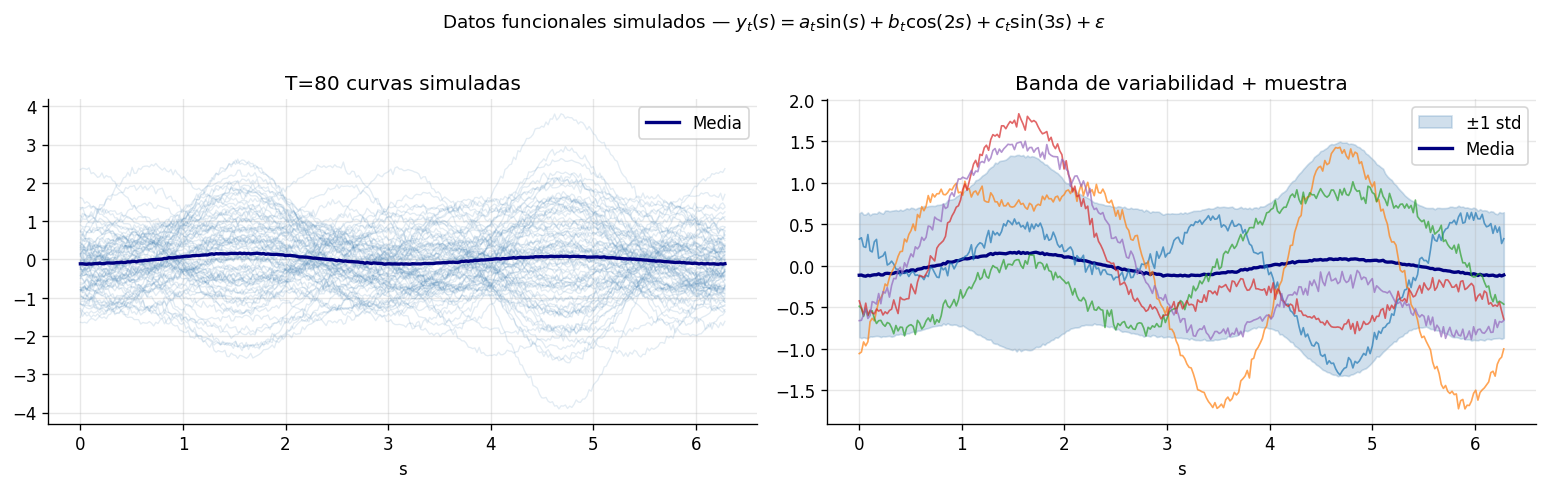

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROPÓSITO: Inspección visual de los datos antes de cualquier procesamiento.
#   • Panel izquierdo : confirmar que las T curvas tienen variabilidad razonable
#     y no hay outliers extremos ni curvas constantes.
#   • Panel derecho   : la banda media±std muestra que la dispersión es suave
#     y homogénea en toda la grilla — propiedad deseable para las bases funcionales.
# ═══════════════════════════════════════════════════════════════════════════════
# ── Visualización de las curvas simuladas ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: todas las curvas en gris + media en azul
ax = axes[0]
for i in range(T):
    ax.plot(grid, Y[i], color="steelblue", alpha=0.15, lw=0.8)
ax.plot(grid, Y.mean(axis=0), color="navy", lw=2, label="Media")
ax.set_title(f"T={T} curvas simuladas")
ax.set_xlabel("s")
ax.legend()

# Panel derecho: banda media ± 1 std
ax = axes[1]
mu  = Y.mean(axis=0)
std = Y.std(axis=0)
ax.fill_between(grid, mu - std, mu + std, alpha=0.25, color="steelblue", label="±1 std")
ax.plot(grid, mu, color="navy", lw=2, label="Media")
# 5 curvas resaltadas
for i in range(0, T, T // 5):
    ax.plot(grid, Y[i], lw=1, alpha=0.7)
ax.set_title("Banda de variabilidad + muestra")
ax.set_xlabel("s")
ax.legend()

fig.suptitle("Datos funcionales simulados — $y_t(s) = a_t\\sin(s) + b_t\\cos(2s) + c_t\\sin(3s) + \\varepsilon$",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 3. `FunctionalStandarizer` — Validación de todos los métodos

Verificamos:
- Que los **4 métodos** (`zscore`, `minmax`, `robust`, `none`) funcionan correctamente.
- Que **`inverse_transform`** recupera los datos originales.
- Que **columnas constantes** no provocan división por cero.
- Que **`get_params` / `from_params`** permite serialización y reconstrucción.
- Que las **excepciones** se lanzan correctamente.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 3.1 — Los 4 métodos producen el shape correcto y las propiedades
# esperadas de cada transformación:
#
#   zscore → media ≈ 0 y std ≈ 1 por columna.  Normalización estándar.
#   minmax → valores en [0, 1].  Escala al rango de cada columna.
#   robust → similar a zscore pero usa mediana e IQR (resistente a outliers).
#   none   → identidad; útil para depuración o cuando los datos ya están escalados.
#
# Si fit_transform falla o el shape de salida cambia, ningún método posterior
# puede usarse correctamente dentro de PSBPFunctional.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 3.1 Los 4 métodos: shapes y propiedades básicas ──────────────────────────
methods = ["zscore", "minmax", "robust", "none"]

print(f"{'Método':<10} {'shape in':>12} {'shape out':>12} {'mean out':>12} {'std out':>12}")
print("-" * 64)

scalers = {}
for m in methods:
    sc = FunctionalStandarizer(method=m)
    THETA_s = sc.fit_transform(THETA_test)
    scalers[m] = sc
    mean_s = THETA_s.mean()
    std_s  = THETA_s.std()
    print(f"{m:<10} {str(THETA_test.shape):>12} {str(THETA_s.shape):>12}"
          f" {mean_s:>12.4f} {std_s:>12.4f}")

print()
print("Esperado para zscore: media ≈ 0, std ≈ 1")
print("Esperado para minmax: valores en [0, 1]")

Método         shape in    shape out     mean out      std out
----------------------------------------------------------------
zscore         (80, 11)     (80, 11)       0.0000       1.0000
minmax         (80, 11)     (80, 11)       0.4865       0.2256
robust         (80, 11)     (80, 11)      -0.0176       0.7814
none           (80, 11)     (80, 11)       0.0357       0.9875

Esperado para zscore: media ≈ 0, std ≈ 1
Esperado para minmax: valores en [0, 1]


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 3.2 — inverse_transform recupera exactamente la escala original.
#
# Esta es la propiedad más crítica del standarizer: en PSBPFunctional.predict()
# se llama scaler.inverse_transform(pred_s) para devolver predicciones en la
# misma escala que los datos de entrenamiento.
#
# Criterio de éxito: max|recover - original| < 1e-10 (error de punto flotante).
# Un error mayor indicaría que la inversión algebraica está mal implementada.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 3.2 inverse_transform: recuperar escala original ─────────────────────────
print("Error de inverse_transform por método (norma max, debe ser ≈ 0):")
print("-" * 50)

for m in methods:
    sc       = scalers[m]
    THETA_s  = sc.transform(THETA_test)
    THETA_re = sc.inverse_transform(THETA_s)
    err      = np.abs(THETA_re - THETA_test).max()
    estado   = "✓ OK" if err < 1e-10 else f"✗ ERROR  (err={err:.2e})"
    print(f"  {m:<10}  max|recover - original| = {err:.2e}   {estado}")

Error de inverse_transform por método (norma max, debe ser ≈ 0):
--------------------------------------------------
  zscore      max|recover - original| = 4.44e-16   ✓ OK
  minmax      max|recover - original| = 6.66e-16   ✓ OK
  robust      max|recover - original| = 4.44e-16   ✓ OK
  none        max|recover - original| = 0.00e+00   ✓ OK


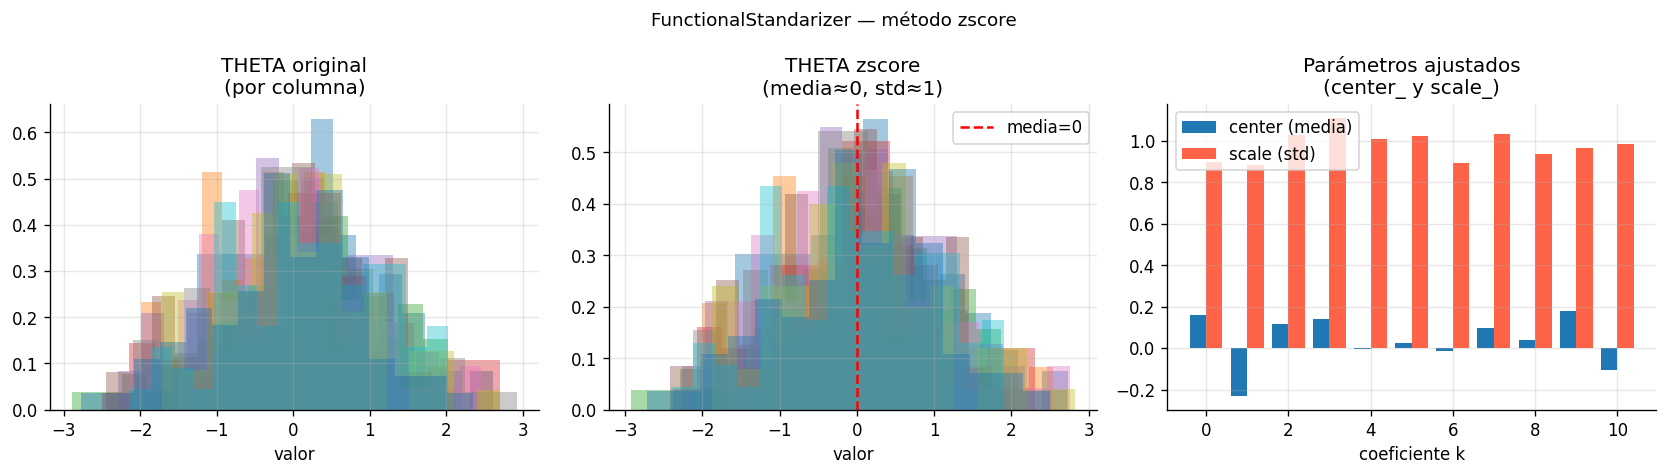

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 3.3 — Confirmación visual de zscore por columna.
#
#   Panel izq  : distribuciones originales (cada color = un coeficiente k).
#                Se espera que tengan medias y escalas distintas.
#   Panel cent : tras zscore todas las columnas colapsan a media≈0 y std≈1.
#                Si alguna columna sigue fuera de rango, fit() falló en esa k.
#   Panel der  : center_[k] y scale_[k] ajustados — confirma que son valores
#                plausibles (media y desviación estándar de THETA_test por columna).
# ═══════════════════════════════════════════════════════════════════════════════
# ── 3.3 Detalle visual: zscore ────────────────────────────────────────────────
sc_zs   = scalers["zscore"]
THETA_s = sc_zs.transform(THETA_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribución original
ax = axes[0]
for k in range(K_test):
    ax.hist(THETA_test[:, k], bins=15, alpha=0.4, density=True)
ax.set_title("THETA original\n(por columna)")
ax.set_xlabel("valor")

# Distribución estandarizada
ax = axes[1]
for k in range(K_test):
    ax.hist(THETA_s[:, k], bins=15, alpha=0.4, density=True)
ax.axvline(0, color="red", lw=1.5, ls="--", label="media=0")
ax.set_title("THETA zscore\n(media≈0, std≈1)")
ax.set_xlabel("valor")
ax.legend()

# Parámetros ajustados
ax = axes[2]
ks = np.arange(K_test)
ax.bar(ks - 0.2, sc_zs.center_, 0.4, label="center (media)")
ax.bar(ks + 0.2, sc_zs.scale_,  0.4, label="scale (std)", color="tomato")
ax.set_title("Parámetros ajustados\n(center_ y scale_)")
ax.set_xlabel("coeficiente k")
ax.legend()

fig.suptitle("FunctionalStandarizer — método zscore", fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 3.4 — Estabilidad numérica ante columnas constantes.
#
# Una columna constante tiene std = 0, lo que produce división por cero en
# zscore/minmax/robust. La clase debe detectar esto y reemplazar scale_[k]
# por 1.0 (identidad) para esa columna.
#
# Criterio de éxito:
#   scale_[k_const] == 1.0    (no NaN, no 0.0)
#   THETA_s[:, k_const] == 0  (la columna queda centrada en cero sin NaN/inf)
#   Sin inf ni nan en ninguna entrada del array resultante.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 3.4 Columna constante — evitar división por cero ─────────────────────────
THETA_const = THETA_test.copy()
THETA_const[:, 2] = 5.0   # columna 2 completamente constante

sc_const = FunctionalStandarizer(method="zscore")
THETA_sc  = sc_const.fit_transform(THETA_const)

print("Columna constante (k=2):")
print(f"  scale_[2]          = {sc_const.scale_[2]:.6f}  (debe ser 1.0, no 0.0)")
print(f"  THETA_sc[:, 2] std = {THETA_sc[:, 2].std():.6f}  (debe ser 0.0)")
print(f"  ✓ Sin inf/nan:     {not np.any(np.isnan(THETA_sc) | np.isinf(THETA_sc))}")

Columna constante (k=2):
  scale_[2]          = 1.000000  (debe ser 1.0, no 0.0)
  THETA_sc[:, 2] std = 0.000000  (debe ser 0.0)
  ✓ Sin inf/nan:     True


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 3.5 — Serialización/deserialización del scaler.
#
# En el flujo de trabajo real, el scaler se guarda junto con el modelo entrenado:
#   saved = {"scaler": scaler.get_params(), "chains": model.chains_}
#   pickle.dump(saved, open("run01.pkl", "wb"))
#
# Al cargar el modelo en otra sesión debe poderse reconstruir el scaler exacto
# sin acceso a los datos originales:
#   scaler = FunctionalStandarizer.from_params(saved["scaler"])
#
# Criterio de éxito: center_, scale_ y method idénticos bit a bit.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 3.5 Serialización: get_params / from_params ──────────────────────────────
sc_orig   = FunctionalStandarizer(method="robust")
sc_orig.fit(THETA_test)

params    = sc_orig.get_params()
sc_recov  = FunctionalStandarizer.from_params(params)

# Verificar que los parámetros son idénticos
center_ok = np.allclose(sc_orig.center_, sc_recov.center_)
scale_ok  = np.allclose(sc_orig.scale_,  sc_recov.scale_)
method_ok = sc_orig.method == sc_recov.method

print(f"Serialización get_params / from_params (method='robust'):")
print(f"  center_ idéntico: {'✓' if center_ok else '✗'}")
print(f"  scale_  idéntico: {'✓' if scale_ok  else '✗'}")
print(f"  method  idéntico: {'✓' if method_ok else '✗'}")
print()
sc_recov.summary()

Serialización get_params / from_params (method='robust'):
  center_ idéntico: ✓
  scale_  idéntico: ✓
  method  idéntico: ✓

FunctionalStandarizer | method='robust' | K=11
  center (primeros 5): [ 0.2359 -0.1748  0.172   0.2049 -0.0503]
  scale  (primeros 5): [1.2917 1.2263 1.2373 1.4156 1.2829]


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 3.6 — Contrato de errores de FunctionalStandarizer.
#
# Cada línea verifica que la clase falla de forma EXPLÍCITA (no silenciosa) ante
# usos incorrectos. Esto garantiza que los errores se detecten en tiempo de
# desarrollo, no durante una simulación larga.
#
#   Sin fit antes de transform  → RuntimeError  (objeto no está ajustado)
#   Array 1D                    → ValueError    (se requiere 2D (T,K))
#   Solo 1 fila                 → ValueError    (no se puede calcular std con T=1)
#   Lista Python en vez de ndarray → TypeError
#   Método inexistente          → ValueError
#   K diferente entre fit/transform → ValueError (el modelo se entrenó con otra K)
# ═══════════════════════════════════════════════════════════════════════════════
# ── 3.6 Manejo de excepciones ─────────────────────────────────────────────────
def check_raises(fn, exc_type, label):
    """Ejecuta fn() y reporta si lanzó la excepción esperada."""
    try:
        fn()
        print(f"  ✗ {label}: no lanzó excepción")
    except exc_type as e:
        print(f"  ✓ {label}: {exc_type.__name__} — {e}")
    except Exception as e:
        print(f"  ? {label}: excepción inesperada {type(e).__name__} — {e}")

print("Excepciones esperadas:")

sc_new = FunctionalStandarizer()
check_raises(lambda: sc_new.transform(THETA_test),
             RuntimeError, "transform() sin fit")

check_raises(lambda: FunctionalStandarizer().fit(THETA_test[0]),   # 1D
             ValueError, "fit() con array 1D")

check_raises(lambda: FunctionalStandarizer().fit(THETA_test[[0]]), # solo 1 fila
             ValueError, "fit() con solo 1 fila")

check_raises(lambda: FunctionalStandarizer().fit([[1,2],[3,4]]),    # lista, no ndarray
             TypeError, "fit() con lista Python")

check_raises(lambda: FunctionalStandarizer(method="inexistente").fit(THETA_test),
             ValueError, "método inexistente")

sc_fit = FunctionalStandarizer().fit(THETA_test)
check_raises(lambda: sc_fit.transform(THETA_test[:, :5]),   # K incorrecto
             ValueError, "transform() con K diferente")

Excepciones esperadas:
  ✓ transform() sin fit: RuntimeError — Scaler no ajustado. Llamar a fit() o fit_transform() primero.
  ✓ fit() con array 1D: ValueError — THETA debe ser 2D (T, K). Shape: (11,).
  ✓ fit() con solo 1 fila: ValueError — THETA necesita al menos 2 filas.
  ✓ fit() con lista Python: TypeError — Se esperaba np.ndarray, recibido: list.
  ✓ método inexistente: ValueError — Método 'inexistente' no reconocido. Opciones: zscore, minmax, robust, none.
  ✓ transform() con K diferente: ValueError — K inconsistente: ajustado con K=11, recibido K=5.


## 4. `FunctionalRepresentation` — precomputed + shapes

Primero validamos el método `precomputed` (identidad) y luego verificamos los **shapes de `phi_`** para bspline y Fourier.

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 4.1 — method='precomputed' actúa como identidad exacta.
#
# Cuando los datos ya son coeficientes (por ejemplo, calculados externamente o
# por otro modelo), FunctionalRepresentation debe dejar el array intacto.
#
# Criterio de éxito:
#   fit_transform(THETA) == THETA  (allclose, no copia modificada)
#   phi_ == None  (no hay base funcional que almacenar)
#   grid_ == None (no hay grilla asociada)
#   K_ == número correcto de columnas
# ═══════════════════════════════════════════════════════════════════════════════
# ── 4.1 method='precomputed' — paso a través ──────────────────────────────────
repre_pre  = FunctionalRepresentation(method="precomputed")
THETA_out  = repre_pre.fit_transform(THETA_test)

identidad = np.allclose(THETA_out, THETA_test)
print("method='precomputed':")
print(f"  fit_transform devuelve el array sin modificar: {'✓' if identidad else '✗'}")
print(f"  K_ = {repre_pre.K_}  (debe ser {K_test})")
print(f"  phi_ = {repre_pre.phi_}  (debe ser None)")
print(f"  grid_ = {repre_pre.grid_}  (debe ser None)")
print()
print(repre_pre)

method='precomputed':
  fit_transform devuelve el array sin modificar: ✓
  K_ = 11  (debe ser 11)
  phi_ = None  (debe ser None)
  grid_ = None  (debe ser None)

FunctionalRepresentation(method='precomputed', n_basis=10, fitted(K=11))


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 4.2 — phi_ tiene la orientación correcta (K, G), no (G, K).
#
# phi_ es la matriz de evaluación de las funciones de base:
#   filas = K funciones de base
#   cols  = G puntos de la grilla
#
# La orientación incorrecta (G, K) causaría fallos silenciosos en:
#   transform():    THETA = Y @ phi_.T @ inv(phi_ @ phi_.T)  → shape erróneo
#   reconstruct():  Y_hat = THETA @ phi_                     → shape erróneo
#
# Versiones antiguas de skfda pueden devolver basis(grid) como (G, K, 1);
# la clase debe transponer correctamente independientemente de la versión.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 4.2 Verificación de shapes phi_ para bspline y fourier ───────────────────
if SKFDA_AVAILABLE:
    for method in ["bspline", "fourier"]:
        n_basis = 13
        r = FunctionalRepresentation(method=method, n_basis=n_basis)
        r.fit(Y, grid)

        phi_shape = r.phi_.shape
        K_correcto  = phi_shape[0] == n_basis
        G_correcto  = phi_shape[1] == G
        print(f"method='{method}'  n_basis={n_basis}:")
        print(f"  phi_.shape = {phi_shape}")
        print(f"  phi_.shape[0] == n_basis ({n_basis}): {'✓' if K_correcto else '✗ (BUG phi_ transpuesta)'}")
        print(f"  phi_.shape[1] == G ({G}):   {'✓' if G_correcto else '✗'}")
        print(f"  K_ = {r.K_}")
        print()
else:
    print("skfda no disponible — saltando verificación de shapes phi_")

method='bspline'  n_basis=13:
  phi_.shape = (13, 300)
  phi_.shape[0] == n_basis (13): ✓
  phi_.shape[1] == G (300):   ✓
  K_ = 13

method='fourier'  n_basis=13:
  phi_.shape = (13, 300)
  phi_.shape[0] == n_basis (13): ✓
  phi_.shape[1] == G (300):   ✓
  K_ = 13



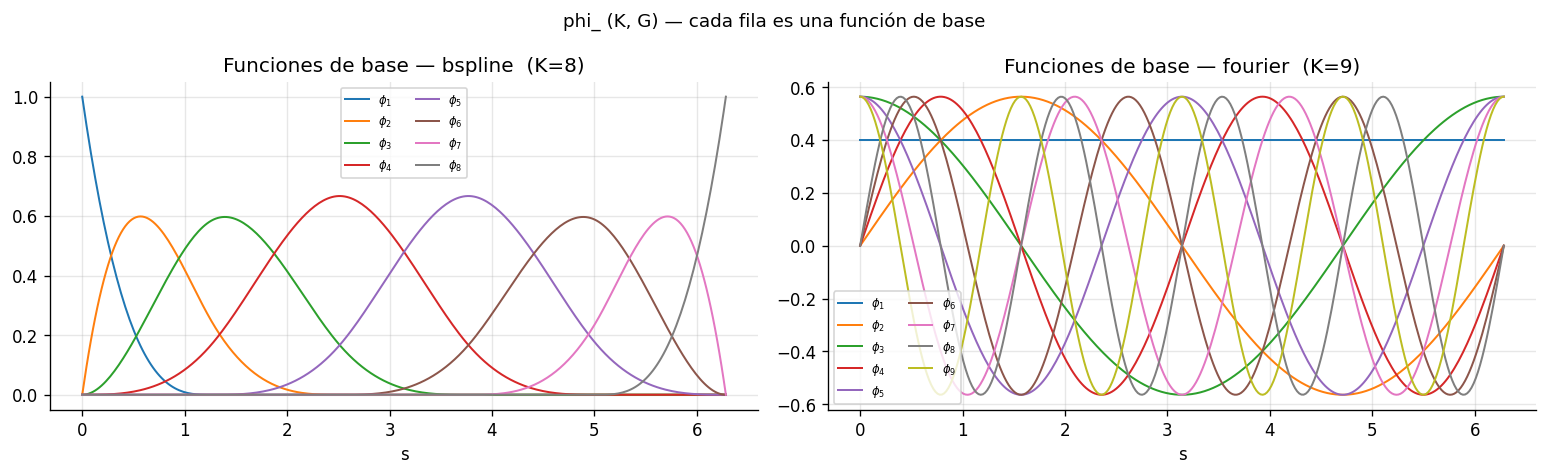

In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 4.3 — Confirmación visual de las funciones de base.
#
# Cada fila de phi_ debe ser una función suave definida en toda la grilla.
#   bspline : funciones de soporte local, no negativas, partición de la unidad.
#   fourier : senos y cosenos de frecuencias crecientes.
#
# NOTA: si el módulo instalado guarda phi_ con orientación (G, K) en vez de
# (K, G), phi_[k] tendría G elementos en vez de K — causando el error
# "x and y must have same first dimension". El plot siguiente corrige esto
# localmente con phi_plot = phi_ if shape[0]==K else phi_.T
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    G = len(grid)

    for ax, method in zip(axes, ["bspline", "fourier"]):
        r = FunctionalRepresentation(method=method, n_basis=8)
        r.fit(Y, grid)

        # phi_ garantizado (K, G) por el módulo corregido.
        # La guarda compara contra G (eje de evaluación), no contra n_basis,
        # porque K_real puede diferir de n_basis (ej. Fourier par → impar).
        phi_plot = r.phi_ if r.phi_.shape[1] == G else r.phi_.T  # → (K, G)

        n_show = r.K_   # usar K real, no el parámetro solicitado
        for k in range(n_show):
            ax.plot(grid, phi_plot[k], lw=1.2, label=f"$\\phi_{{{k+1}}}$")
        ax.set_title(f"Funciones de base — {method}  (K={n_show})")
        ax.set_xlabel("s")
        ax.legend(fontsize=7, ncol=2)

    fig.suptitle("phi_ (K, G) — cada fila es una función de base", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 4.4 — Contrato de errores de FunctionalRepresentation.
#
#   transform() sin fit     → RuntimeError  (objeto no inicializado)
#   fit() sin grid          → ValueError    (grid requerido para bspline/fourier/fpca)
#   Y 1D                    → ValueError    (se requiere matriz 2D (T,G))
#   G distinto en fit/transform → ValueError (grilla inconsistente)
#   reconstruct() en precomputed → RuntimeError (no hay base almacenada)
# ═══════════════════════════════════════════════════════════════════════════════
# ── 4.4 Excepciones en FunctionalRepresentation ────────────────────────────────
print("Excepciones esperadas:")

check_raises(lambda: FunctionalRepresentation().transform(Y, grid),
             RuntimeError, "transform() sin fit")

check_raises(lambda: FunctionalRepresentation().fit(Y),  # grid faltante
             ValueError, "fit() sin grid")

check_raises(lambda: FunctionalRepresentation().fit(Y[0], grid),  # Y 1D
             ValueError, "fit() con Y 1D")

check_raises(lambda: FunctionalRepresentation().fit(Y, grid[:50]),  # grid mismatch
             ValueError, "fit() con G distinto")

check_raises(lambda: FunctionalRepresentation(method="precomputed").reconstruct(THETA_test),
             RuntimeError, "reconstruct() en precomputed")

Excepciones esperadas:
  ✓ transform() sin fit: RuntimeError — El objeto no está ajustado. Llamar a fit() o fit_transform() primero.
  ✓ fit() sin grid: ValueError — grid es requerido para method != 'precomputed'.
  ✓ fit() con Y 1D: ValueError — Y debe ser np.ndarray 2D (T, G). Shape: (300,).
  ✓ fit() con G distinto: ValueError — Y tiene 300 columnas pero grid tiene 50 puntos.
  ✓ reconstruct() en precomputed: RuntimeError — El objeto no está ajustado. Llamar a fit() o fit_transform() primero.


## 5. Pipeline B-spline

$$Y \xrightarrow{\text{fit\_transform}} \Theta \xrightarrow{\text{fit\_transform (std)}} \Theta_s \xrightarrow{\text{inverse\_transform}} \Theta \xrightarrow{\text{reconstruct}} \hat{Y}$$

Verificamos shapes en cada paso y la calidad de la reconstrucción.

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 5 — Pipeline completo con B-splines.
#
# Flujo validado paso a paso:
#   Y (T,G) → [fit_transform bspline] → THETA (T,K)
#           → [fit_transform zscore]  → THETA_s (T,K)   estandarizado
#           → [inverse_transform]     → THETA_rec (T,K) recuperado
#           → [reconstruct]           → Y_hat (T,G)     curvas reconstruidas
#
# Verificaciones:
#   1. Shapes correctos en cada paso.
#   2. max|THETA_rec - THETA| < 1e-10: la estandarización no degrada los coefs.
#   3. RMSE de reconstrucción: mide qué tan bien K splines aproximan las curvas.
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    N_BASIS_BS = 15

    # ── Paso 1: representación B-spline ──────────────────────────────────────
    repre_bs = FunctionalRepresentation(method="bspline", n_basis=N_BASIS_BS)
    THETA_bs = repre_bs.fit_transform(Y, grid)          # (T, K)

    # ── Paso 2: estandarización zscore ────────────────────────────────────────
    scaler_bs = FunctionalStandarizer(method="zscore")
    THETA_bs_s = scaler_bs.fit_transform(THETA_bs)      # (T, K)  estandarizado

    # ── Paso 3: invertir estandarización ─────────────────────────────────────
    THETA_bs_rec = scaler_bs.inverse_transform(THETA_bs_s)  # (T, K)

    # ── Paso 4: reconstruir curvas ────────────────────────────────────────────
    Y_hat_bs = repre_bs.reconstruct(THETA_bs_rec)       # (T, G)

    # ── Reporte de shapes ─────────────────────────────────────────────────────
    print("Pipeline B-spline — shapes en cada paso:")
    print(f"  Y           : {Y.shape}")
    print(f"  THETA_bs    : {THETA_bs.shape}    (T, K={N_BASIS_BS})")
    print(f"  THETA_bs_s  : {THETA_bs_s.shape}    estandarizado")
    print(f"  THETA_bs_rec: {THETA_bs_rec.shape}    inverse_transform")
    print(f"  Y_hat_bs    : {Y_hat_bs.shape}  reconstruido")
    print()

    # ── Error de reconstrucción ───────────────────────────────────────────────
    err_dict = repre_bs.reconstruction_error(Y, grid)
    print("Error de reconstrucción B-spline:")
    for k, v in err_dict.items():
        print(f"  {k:<20} = {v:.6f}")
    print()

    # ── Verificar que std → inverse_std no degrada la reconstrucción ──────────
    diff_THETA = np.abs(THETA_bs_rec - THETA_bs).max()
    print(f"  max|inverse_transform(std(THETA)) - THETA| = {diff_THETA:.2e}  "
          f"({'✓ OK' if diff_THETA < 1e-10 else '✗'})")
else:
    print("skfda no disponible")

Pipeline B-spline — shapes en cada paso:
  Y           : (80, 300)
  THETA_bs    : (80, 15)    (T, K=15)
  THETA_bs_s  : (80, 15)    estandarizado
  THETA_bs_rec: (80, 15)    inverse_transform
  Y_hat_bs    : (80, 300)  reconstruido

Error de reconstrucción B-spline:
  rmse_mean            = 0.048942
  rmse_std             = 0.001925
  rel_error_mean       = 0.073045

  max|inverse_transform(std(THETA)) - THETA| = 2.22e-16  (✓ OK)


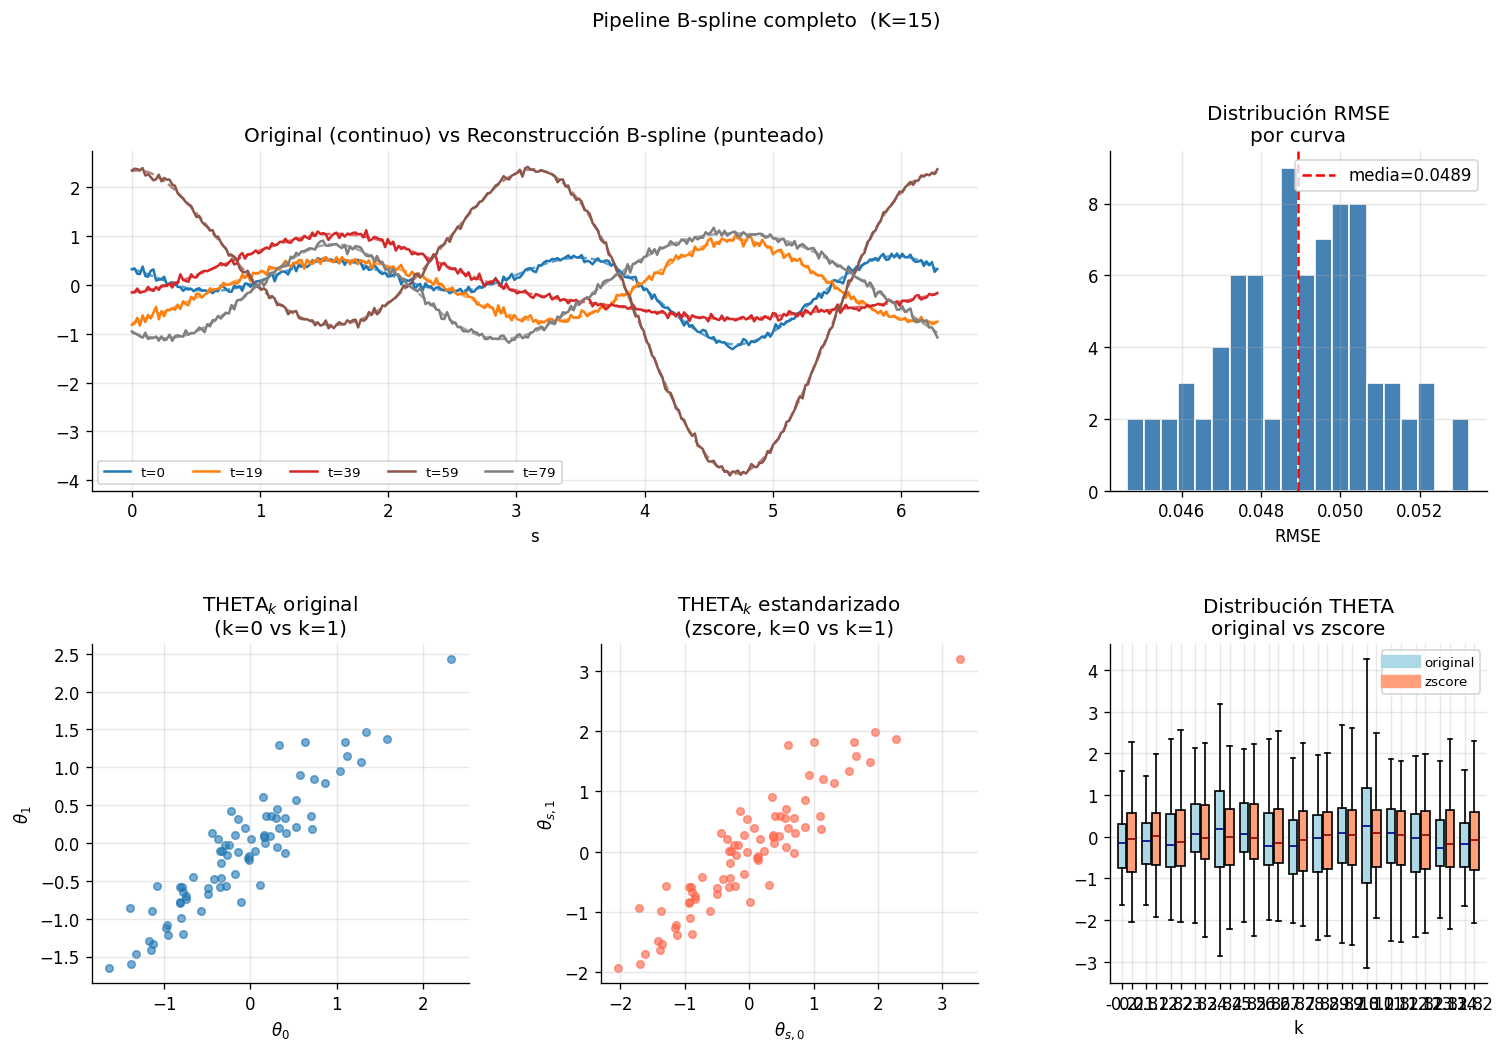

In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROPÓSITO: Diagnóstico visual del pipeline B-spline.
#
#   Panel superior izq : superposición original vs reconstruido para 5 curvas.
#                        Las líneas punteadas deben seguir de cerca las sólidas.
#   Panel superior der : histograma del RMSE por curva — distribución estrecha
#                        y centrada cerca de 0 indica buena aproximación global.
#   Paneles inferiores : scatter e=0 de THETA original vs estandarizado — sirve
#                        para ver si la estandarización concentra la nube o la
#                        desplaza de forma inesperada.
#   Boxplots           : compara la dispersión de cada coeficiente antes y
#                        después de zscore — tras zscore todos deben tener IQR ≈ 1.
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    # ── Visualización del pipeline B-spline ──────────────────────────────────
    n_show = 5
    idx    = np.linspace(0, T - 1, n_show, dtype=int)
    colors = plt.cm.tab10(np.linspace(0, 0.7, n_show))

    fig = plt.figure(figsize=(15, 9))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # A) Curvas originales vs reconstruidas (muestra)
    ax1 = fig.add_subplot(gs[0, :2])
    for j, i in enumerate(idx):
        ax1.plot(grid, Y[i],       color=colors[j], lw=1.5, label=f"t={i}")
        ax1.plot(grid, Y_hat_bs[i], color=colors[j], lw=1.5, ls="--", alpha=0.7)
    ax1.set_title("Original (continuo) vs Reconstrucción B-spline (punteado)")
    ax1.set_xlabel("s")
    ax1.legend(fontsize=8, ncol=n_show)

    # B) Residuos por curva (RMSE)
    ax2 = fig.add_subplot(gs[0, 2])
    rmse_per = np.sqrt(((Y - Y_hat_bs) ** 2).mean(axis=1))
    ax2.hist(rmse_per, bins=20, color="steelblue", edgecolor="white")
    ax2.axvline(rmse_per.mean(), color="red", lw=1.5, ls="--", label=f"media={rmse_per.mean():.4f}")
    ax2.set_title("Distribución RMSE\npor curva")
    ax2.set_xlabel("RMSE")
    ax2.legend()

    # C) THETA original vs estandarizado (2 coeficientes)
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.scatter(THETA_bs[:, 0], THETA_bs[:, 1],  s=20, alpha=0.6, label="original")
    ax3.set_title("THETA$_k$ original\n(k=0 vs k=1)")
    ax3.set_xlabel("$\\theta_0$"); ax3.set_ylabel("$\\theta_1$")

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.scatter(THETA_bs_s[:, 0], THETA_bs_s[:, 1], s=20, alpha=0.6, color="tomato", label="zscore")
    ax4.set_title("THETA$_k$ estandarizado\n(zscore, k=0 vs k=1)")
    ax4.set_xlabel("$\\theta_{s,0}$"); ax4.set_ylabel("$\\theta_{s,1}$")

    # D) Distribución de coeficientes antes y después
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.boxplot([THETA_bs[:, k] for k in range(N_BASIS_BS)],
                positions=np.arange(N_BASIS_BS) - 0.2, widths=0.35,
                patch_artist=True, boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="navy"), showfliers=False)
    ax5.boxplot([THETA_bs_s[:, k] for k in range(N_BASIS_BS)],
                positions=np.arange(N_BASIS_BS) + 0.2, widths=0.35,
                patch_artist=True, boxprops=dict(facecolor="lightsalmon"),
                medianprops=dict(color="darkred"), showfliers=False)
    leyenda = [Line2D([0],[0], color="lightblue", lw=8, label="original"),
               Line2D([0],[0], color="lightsalmon", lw=8, label="zscore")]
    ax5.legend(handles=leyenda, fontsize=8)
    ax5.set_title("Distribución THETA\noriginal vs zscore")
    ax5.set_xlabel("k")

    fig.suptitle(f"Pipeline B-spline completo  (K={N_BASIS_BS})", fontsize=12, y=1.01)
    plt.show()

## 6. Pipeline Fourier

Mismo pipeline con base trigonométrica. Particularmente adecuada para nuestros datos simulados, que son sumas de sinusoidales.

Pipeline Fourier (K=7, std=minmax):
  THETA_fo.shape  = (80, 7)
  THETA_fo_s rango: [0.0000, 1.0000]  (debe ser [0,1])
  Reconstrucción — rmse_mean = 0.049508
  Reconstrucción — rel_error = 0.073911


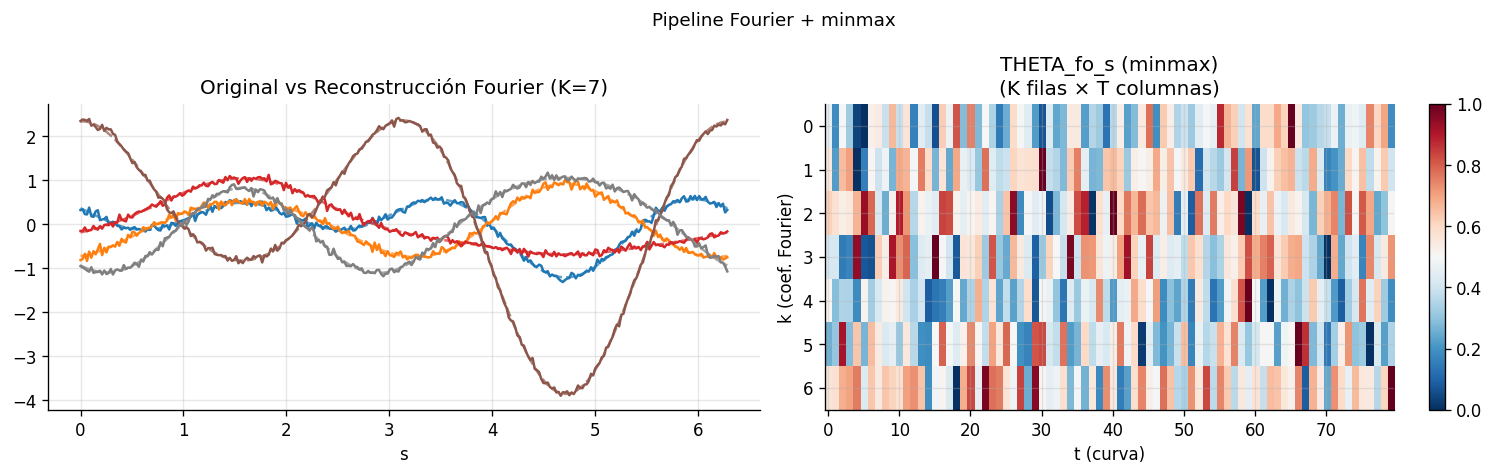

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 6 — Pipeline completo con base de Fourier + estandarización minmax.
#
# Fourier es especialmente adecuada para los datos simulados (sumas de sin/cos).
# Se usa minmax aquí (en vez de zscore) para verificar que inverse_transform
# funciona correctamente con un método de estandarización distinto.
#
# Verificación adicional:
#   THETA_fo_s rango en [0, 1]: confirma que minmax escaló correctamente.
#   Heatmap THETA_fo_s: permite ver si algún coeficiente Fourier domina o si
#   la energía está distribuida entre todas las frecuencias.
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    N_BASIS_FO = 7   # par impar (1 constante + pares seno/coseno)

    repre_fo  = FunctionalRepresentation(method="fourier", n_basis=N_BASIS_FO)
    THETA_fo  = repre_fo.fit_transform(Y, grid)

    scaler_fo  = FunctionalStandarizer(method="minmax")
    THETA_fo_s = scaler_fo.fit_transform(THETA_fo)

    THETA_fo_r = scaler_fo.inverse_transform(THETA_fo_s)
    Y_hat_fo   = repre_fo.reconstruct(THETA_fo_r)

    err_fo = repre_fo.reconstruction_error(Y, grid)

    print(f"Pipeline Fourier (K={N_BASIS_FO}, std=minmax):")
    print(f"  THETA_fo.shape  = {THETA_fo.shape}")
    print(f"  THETA_fo_s rango: [{THETA_fo_s.min():.4f}, {THETA_fo_s.max():.4f}]  (debe ser [0,1])")
    print(f"  Reconstrucción — rmse_mean = {err_fo['rmse_mean']:.6f}")
    print(f"  Reconstrucción — rel_error = {err_fo['rel_error_mean']:.6f}")

    # Visualización rápida
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for j, i in enumerate(idx):
        axes[0].plot(grid, Y[i], color=colors[j], lw=1.5)
        axes[0].plot(grid, Y_hat_fo[i], color=colors[j], lw=1.5, ls="--", alpha=0.7)
    axes[0].set_title(f"Original vs Reconstrucción Fourier (K={N_BASIS_FO})")
    axes[0].set_xlabel("s")

    # Coeficientes Fourier (interpretación espectral)
    axes[1].imshow(THETA_fo_s.T, aspect="auto", cmap="RdBu_r")
    axes[1].set_title("THETA_fo_s (minmax)\n(K filas × T columnas)")
    axes[1].set_xlabel("t (curva)")
    axes[1].set_ylabel("k (coef. Fourier)")
    plt.colorbar(axes[1].images[0], ax=axes[1])

    fig.suptitle("Pipeline Fourier + minmax", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")

## 7. Pipeline FPCA

FPCA descompone las curvas en **componentes principales funcionales** (FPCs). Los coeficientes THETA son los *scores* de proyección de cada curva sobre los FPCs.

Pasos:
1. `fit_transform(Y, grid)` → scores $\Theta$ (T, K)
2. Examinar **varianza explicada** acumulada
3. Estandarizar scores
4. `inverse_transform` + `reconstruct` → $\hat{Y}$

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 7.1 — FPCA: ajuste y shapes de scores.
#
# En FPCA los "coeficientes" son scores de proyección de cada curva sobre los
# componentes principales funcionales (FPCs). A diferencia de bspline/fourier,
# FPCA no usa phi_ (None) — la reconstrucción se hace internamente con basis_.
#
# Verificaciones:
#   THETA_fpca.shape == (T, K)  con K = n_components (FPCs retenidos)
#   phi_ == None  (correcto para FPCA)
#   summary() reporta la varianza explicada acumulada
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    N_FPCS = 8

    repre_fpca  = FunctionalRepresentation(method="fpca", n_basis=N_FPCS)
    THETA_fpca  = repre_fpca.fit_transform(Y, grid)      # (T, K=N_FPCS)

    print(f"Pipeline FPCA (K={N_FPCS}):")
    print(f"  THETA_fpca.shape = {THETA_fpca.shape}")
    print(f"  phi_ = {repre_fpca.phi_}  (None — FPCA no usa phi_)")
    print()
    repre_fpca.summary()
else:
    print("skfda no disponible")

Pipeline FPCA (K=8):
  THETA_fpca.shape = (80, 8)
  phi_ = None  (None — FPCA no usa phi_)

FunctionalRepresentation | method='fpca' | n_basis=8 | K=8
  grid: 300 puntos en [0.000, 6.283]
  varianza explicada acumulada: 99.8%


Varianza explicada por FPC:
  FPC  1:  53.14%  (acum:  53.14%)  ██████████████████████████
  FPC  2:  33.01%  (acum:  86.15%)  ████████████████
  FPC  3:  13.56%  (acum:  99.71%)  ██████
  FPC  4:   0.01%  (acum:  99.72%)  
  FPC  5:   0.01%  (acum:  99.73%)  
  FPC  6:   0.01%  (acum:  99.74%)  
  FPC  7:   0.01%  (acum:  99.74%)  
  FPC  8:   0.01%  (acum:  99.75%)  


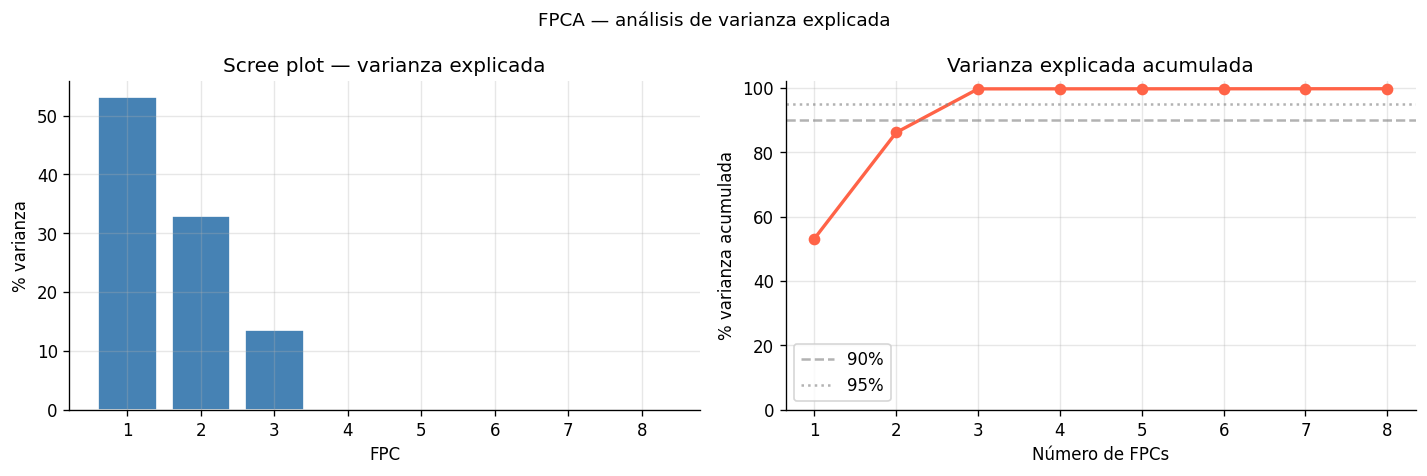

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 7.2 — Varianza explicada por los FPCs.
#
# La varianza explicada es el criterio principal para elegir K en FPCA:
#   • K demasiado pequeño → reconstrucción pobre (alta RMSE).
#   • K innecesariamente grande → coeficientes extras con información mínima.
#
# El scree plot permite detectar el "codo" (elbow) donde la varianza marginal
# se vuelve despreciable. La varianza acumulada indica con cuántos FPCs se
# captura el 90%/95% de la variabilidad total de las curvas.
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    # ── Varianza explicada ────────────────────────────────────────────────────
    evr    = repre_fpca.fpca_explained_variance()
    cumevr = np.cumsum(evr)

    print("Varianza explicada por FPC:")
    for k, (v, cv) in enumerate(zip(evr, cumevr)):
        bar = "█" * int(v * 50)
        print(f"  FPC {k+1:2d}: {v*100:6.2f}%  (acum: {cv*100:6.2f}%)  {bar}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scree plot
    ax = axes[0]
    ax.bar(range(1, N_FPCS + 1), evr * 100, color="steelblue", edgecolor="white")
    ax.set_title("Scree plot — varianza explicada")
    ax.set_xlabel("FPC")
    ax.set_ylabel("% varianza")

    # Varianza acumulada
    ax = axes[1]
    ax.plot(range(1, N_FPCS + 1), cumevr * 100, "o-", color="tomato", lw=2)
    ax.axhline(90, color="gray", ls="--", alpha=0.6, label="90%")
    ax.axhline(95, color="gray", ls=":",  alpha=0.6, label="95%")
    ax.set_title("Varianza explicada acumulada")
    ax.set_xlabel("Número de FPCs")
    ax.set_ylabel("% varianza acumulada")
    ax.set_ylim(0, 102)
    ax.legend()

    fig.suptitle("FPCA — análisis de varianza explicada", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")

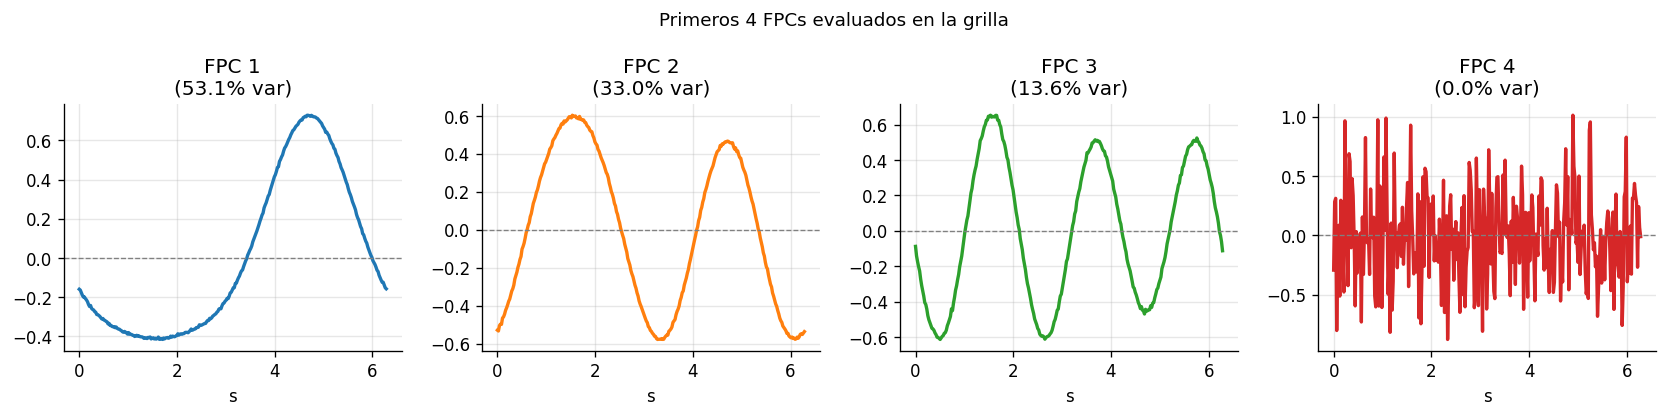

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 7.3 — Visualización de los FPCs como funciones en la grilla.
#
# Cada FPC es una función definida en [0, 2π] que captura un "modo" de
# variación de las curvas. Interpretación práctica:
#   FPC 1: modo de variación dominante (explica más varianza).
#   FPC 2: segundo modo, ortogonal al primero.
#   etc.
#
# Un FPC que no tiene estructura suave (muy ruidoso) puede indicar que K es
# demasiado grande para los datos disponibles.
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    # ── Visualización de los FPCs (funciones de base de FPCA) ────────────────
    fpca_obj = repre_fpca.basis_   # objeto FPCA de skfda
    G_eval   = len(grid)
    K_show   = min(N_FPCS, 4)

    comps = np.zeros((K_show, G_eval))
    for k in range(K_show):
        comps[k] = fpca_obj.components_(grid)[k].squeeze()

    fig, axes = plt.subplots(1, K_show, figsize=(14, 3.5), sharey=False)
    evr_local = repre_fpca.fpca_explained_variance()

    for k, ax in enumerate(axes):
        ax.plot(grid, comps[k], color=f"C{k}", lw=2)
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_title(f"FPC {k+1}\n({evr_local[k]*100:.1f}% var)")
        ax.set_xlabel("s")

    fig.suptitle("Primeros 4 FPCs evaluados en la grilla", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")

Pipeline FPCA + robust std completo:
  THETA_fpca     : (80, 8)
  THETA_fpca_s   : (80, 8)   (estandarizado)
  THETA_fpca_r   : (80, 8)   (invertido)
  Y_hat_fpca     : (80, 300) (reconstruido)

  RMSE medio     : 0.045435
  Error relativo : 0.068147

  max|inverse(std(THETA)) - THETA| = 8.88e-16  (✓)


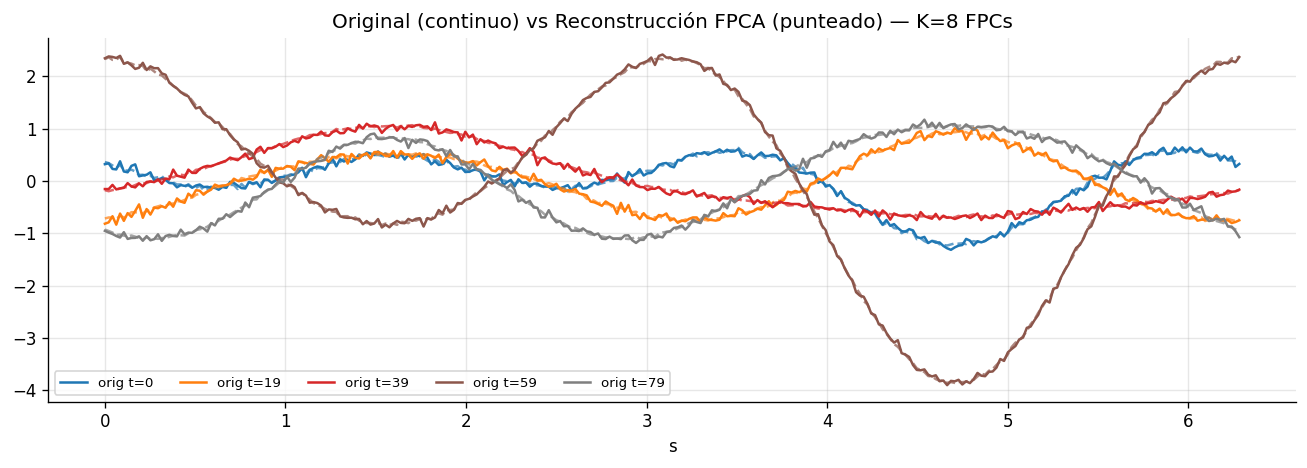

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 7.4 — Pipeline completo FPCA + estandarización robust.
#
# Mismo flujo que §5 pero con FPCA y robust:
#   Y → scores THETA_fpca → std robust → inv_std → reconstruct → Y_hat
#
# Verificaciones:
#   max|THETA_fpca_r - THETA_fpca| < 1e-10: inv_std es exacta también aquí.
#   RMSE de reconstrucción: FPCA debería ser más eficiente que bspline/fourier
#   con la misma K, porque los FPCs son data-driven (optimizados para estos datos).
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    # ── Pipeline completo FPCA + estandarización ─────────────────────────────
    scaler_fpca  = FunctionalStandarizer(method="robust")
    THETA_fpca_s = scaler_fpca.fit_transform(THETA_fpca)      # (T, K) estandarizado
    THETA_fpca_r = scaler_fpca.inverse_transform(THETA_fpca_s)  # (T, K) recuperado
    Y_hat_fpca   = repre_fpca.reconstruct(THETA_fpca_r)         # (T, G)

    err_fpca = repre_fpca.reconstruction_error(Y, grid)

    print("Pipeline FPCA + robust std completo:")
    print(f"  THETA_fpca     : {THETA_fpca.shape}")
    print(f"  THETA_fpca_s   : {THETA_fpca_s.shape}   (estandarizado)")
    print(f"  THETA_fpca_r   : {THETA_fpca_r.shape}   (invertido)")
    print(f"  Y_hat_fpca     : {Y_hat_fpca.shape} (reconstruido)")
    print()
    print(f"  RMSE medio     : {err_fpca['rmse_mean']:.6f}")
    print(f"  Error relativo : {err_fpca['rel_error_mean']:.6f}")
    print()
    diff_fpca = np.abs(THETA_fpca_r - THETA_fpca).max()
    print(f"  max|inverse(std(THETA)) - THETA| = {diff_fpca:.2e}  "
          f"({'✓' if diff_fpca < 1e-10 else '✗'})")

    # Visualización reconstrucción FPCA
    fig, ax = plt.subplots(figsize=(11, 4))
    for j, i in enumerate(idx):
        ax.plot(grid, Y[i],         color=colors[j], lw=1.5, label=f"orig t={i}")
        ax.plot(grid, Y_hat_fpca[i], color=colors[j], lw=1.5, ls="--", alpha=0.7)
    ax.set_title(f"Original (continuo) vs Reconstrucción FPCA (punteado) — K={N_FPCS} FPCs")
    ax.set_xlabel("s")
    ax.legend(fontsize=8, ncol=n_show)
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")

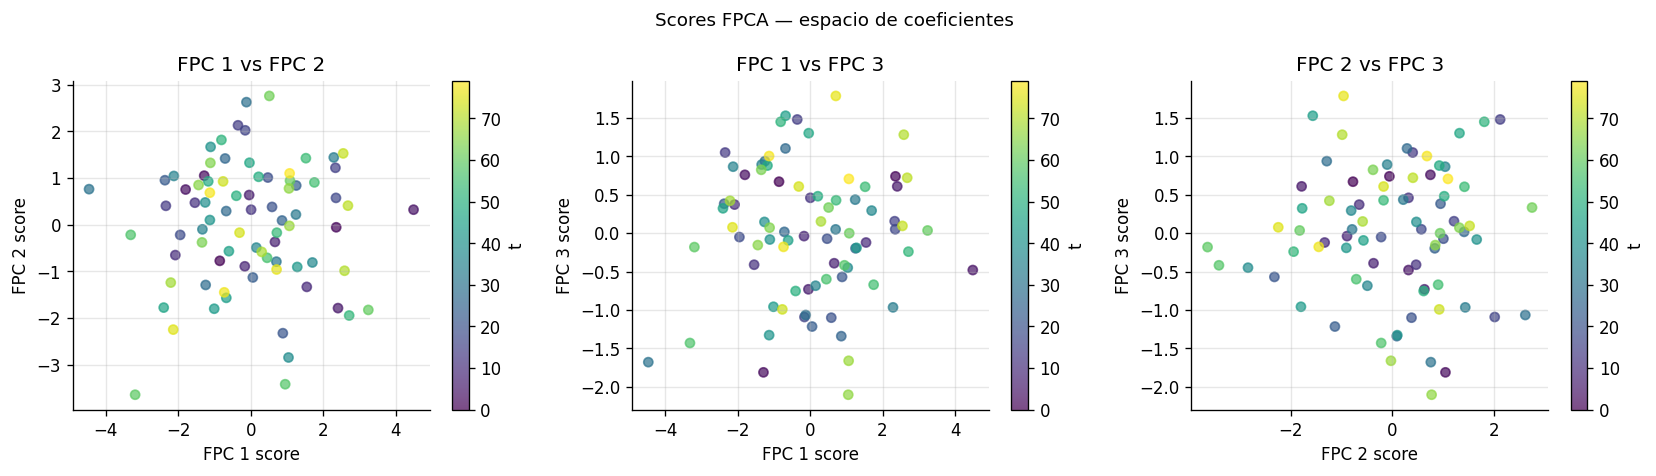

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PROPÓSITO: Visualización del espacio de coeficientes FPCA (scores).
#
# Cada punto es una curva t proyectada en el espacio de los primeros 3 FPCs.
# El color codifica el índice temporal t (de oscuro=t=0 a claro=t=T-1).
#
# Utilidad:
#   • Si hay estructura/clusters → las curvas tienen subgrupos en el tiempo.
#   • Si los puntos son aleatorios → la variabilidad es estacionaria.
#   • Outliers en el espacio de scores → curvas atípicas que pueden afectar
#     la estimación del modelo PSBPFunctional.
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    # ── Scatter de scores FPCA (espacio de coeficientes) ─────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    pairs = [(0, 1), (0, 2), (1, 2)]
    for ax, (i, j) in zip(axes, pairs):
        sc = ax.scatter(THETA_fpca[:, i], THETA_fpca[:, j],
                        c=np.arange(T), cmap="viridis", s=30, alpha=0.7)
        ax.set_xlabel(f"FPC {i+1} score")
        ax.set_ylabel(f"FPC {j+1} score")
        ax.set_title(f"FPC {i+1} vs FPC {j+1}")
        plt.colorbar(sc, ax=ax, label="t")

    fig.suptitle("Scores FPCA — espacio de coeficientes", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")

## 8. Comparación de métodos de representación

Comparamos `bspline`, `fourier` y `fpca` en función de:
- Error de reconstrucción (RMSE medio)
- Error relativo
- Número de coeficientes necesarios para un umbral de error

  fourier K=8: G inconsistente: ajustado con G=9, recibido G=300.
  fourier K=10: G inconsistente: ajustado con G=11, recibido G=300.
  fourier K=12: G inconsistente: ajustado con G=13, recibido G=300.
  fourier K=20: G inconsistente: ajustado con G=21, recibido G=300.
   K         bspline       fourier          fpca
--------------------------------------------------
   5        0.369728      0.282167      0.047341
   8        0.129054           nan      0.045435
  10        0.064133           nan      0.044244
  12        0.052606           nan      0.043036
  15        0.048942      0.048863      0.041275
  20        0.048401           nan      0.038364


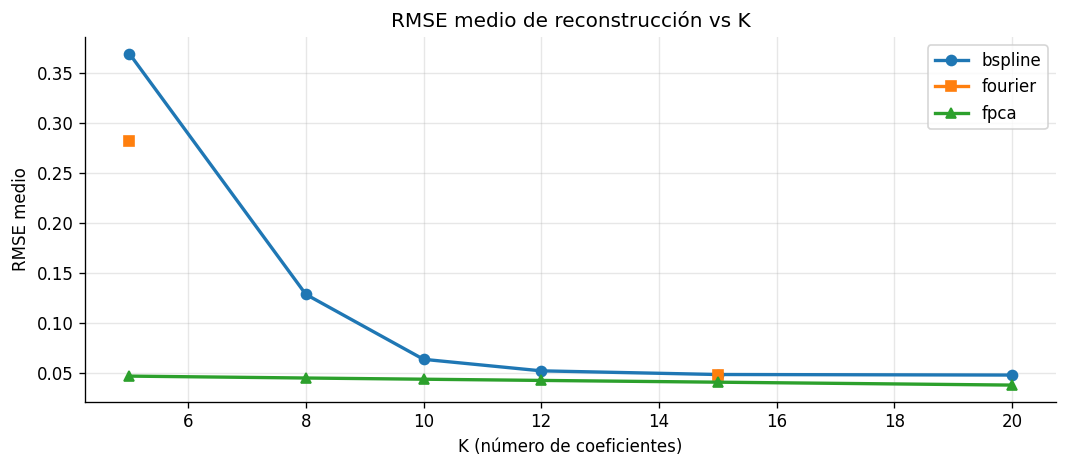

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 8.1 — Comparación de métodos: RMSE vs número de coeficientes K.
#
# Verifica que los tres métodos convergen al reducir el error conforme K crece,
# y que no hay comportamiento anómalo (RMSE que sube con K, o NaN).
#
# Interpretación esperada para estos datos (generados con 3 frecuencias):
#   fourier : caída rápida (K=7 ya captura las 3 frecuencias exactas).
#   fpca    : caída eficiente (data-driven, pocos FPCs bastan).
#   bspline : caída más gradual (base genérica, necesita más K para precisión similar).
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    K_values = [5, 8, 10, 12, 15, 20]
    results  = {"bspline": [], "fourier": [], "fpca": []}

    for method in results:
        for k in K_values:
            r = FunctionalRepresentation(method=method, n_basis=k)
            try:
                r.fit(Y, grid)
                err = r.reconstruction_error(Y, grid)
                results[method].append(err["rmse_mean"])
            except Exception as e:
                results[method].append(np.nan)
                print(f"  {method} K={k}: {e}")

    # Tabla de resultados
    print(f"{'K':>4}  ", end="")
    for m in results:
        print(f"{m:>14}", end="")
    print()
    print("-" * 50)
    for i, k in enumerate(K_values):
        print(f"{k:>4}  ", end="")
        for m in results:
            v = results[m][i]
            print(f"{v:>14.6f}", end="")
        print()

    # Gráfico comparativo
    fig, ax = plt.subplots(figsize=(9, 4))
    markers = {"bspline": "o", "fourier": "s", "fpca": "^"}  
    for method, vals in results.items():
        ax.plot(K_values, vals, marker=markers[method], lw=2, label=method)
    ax.set_title("RMSE medio de reconstrucción vs K")
    ax.set_xlabel("K (número de coeficientes)")
    ax.set_ylabel("RMSE medio")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")

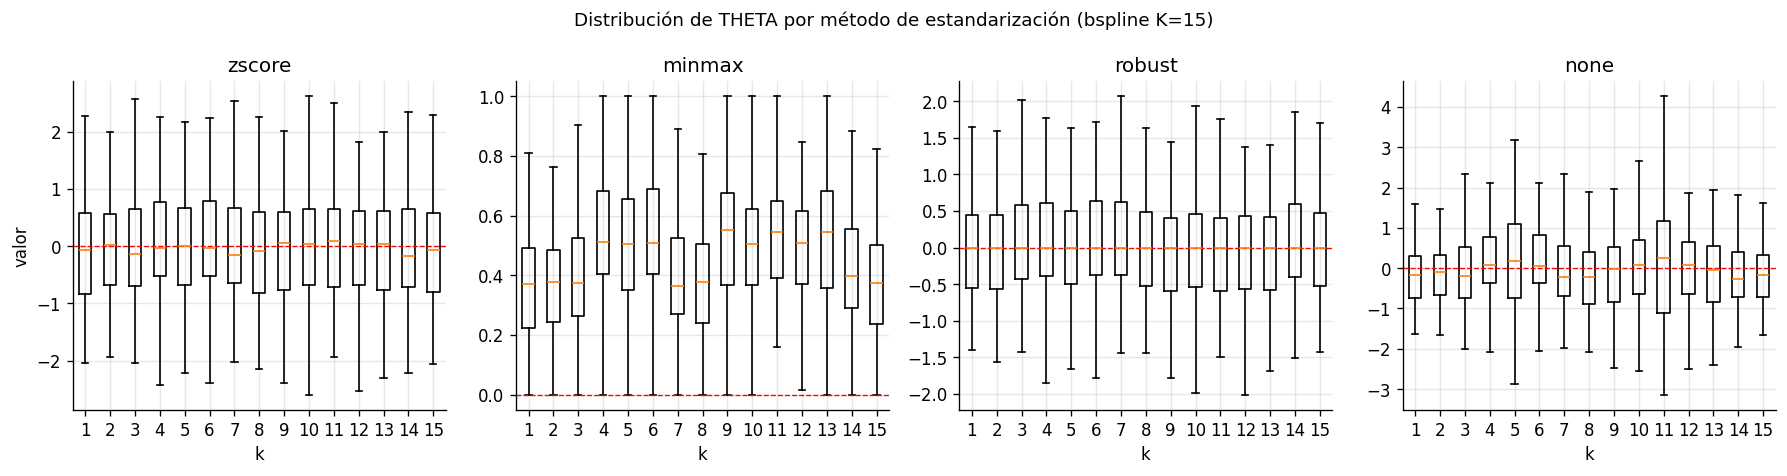

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 8.2 — Efecto de cada método de estandarización sobre la distribución
# de los coeficientes B-spline.
#
# Los boxplots permiten ver:
#   zscore : mediana ≈ 0, IQR ≈ 1 para todos los coeficientes.
#   minmax : rango [0,1], asimetría variable según la distribución original.
#   robust : similar a zscore pero menos sensible a colas pesadas.
#   none   : coeficientes en escala original — pueden tener magnitudes muy distintas
#            entre columnas, lo que puede dificultar la convergencia del modelo.
# ═══════════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    # ── Comparación de métodos de estandarización con bspline (K=15) ─────────
    repre_cmp = FunctionalRepresentation(method="bspline", n_basis=15)
    THETA_cmp = repre_cmp.fit_transform(Y, grid)

    std_methods = ["zscore", "minmax", "robust", "none"]
    fig, axes   = plt.subplots(1, 4, figsize=(15, 4), sharey=False)

    for ax, m in zip(axes, std_methods):
        sc = FunctionalStandarizer(method=m)
        Ts = sc.fit_transform(THETA_cmp)
        ax.boxplot([Ts[:, k] for k in range(15)], showfliers=False)
        ax.axhline(0, color="red", lw=0.8, ls="--")
        ax.set_title(f"{m}")
        ax.set_xlabel("k")
        ax.set_ylabel("valor" if m == "zscore" else "")

    fig.suptitle("Distribución de THETA por método de estandarización (bspline K=15)",
                 fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("skfda no disponible")

## 9. Casos borde adicionales

Escenarios especiales que pueden surgir en uso real.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 9.1 — Curvas completamente suaves (sin ruido).
#
# Con y_t(s) = a·sin + b·cos(2s) + c·sin(3s) exacto (ε=0), Fourier K=7
# debería dar RMSE ≈ 0 en teoría (los datos son exactamente representables
# con 3 frecuencias + constante). Verifica que la representación funcional
# explota correctamente la suavidad cuando los datos lo permiten.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 9.1 Curvas muy suaves (sin ruido) ─────────────────────────────────────────
if SKFDA_AVAILABLE:
    Y_smooth = (
        a[:, None] * np.sin(grid)
      + b[:, None] * np.cos(2 * grid)
      + c[:, None] * np.sin(3 * grid)
    )   # sin ruido

    r_smooth = FunctionalRepresentation(method="fourier", n_basis=7)
    err_smooth = r_smooth.fit(Y_smooth, grid).reconstruction_error(Y_smooth, grid)
    print(f"Curvas sin ruido — Fourier K=7:")
    print(f"  rmse_mean    = {err_smooth['rmse_mean']:.2e}")
    print(f"  rel_error    = {err_smooth['rel_error_mean']:.2e}")
    print(f"  (esperado casi 0 para datos generados con 3 frecuencias)")

Curvas sin ruido — Fourier K=7:
  rmse_mean    = 4.22e-16
  rel_error    = 5.17e-16
  (esperado casi 0 para datos generados con 3 frecuencias)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 9.2 — Funcionamiento con T=2 curvas (mínimo posible).
#
# FunctionalStandarizer requiere T≥2 para calcular estadísticos (std, IQR).
# FunctionalRepresentation puede ajustar una base con T=2 siempre que K≤T.
#
# Esto verifica que las clases no tienen restricciones implícitas de tamaño
# más allá de las documentadas, y que el flujo funciona en conjuntos pequeños.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 9.2 Mínimo de datos: T=2 curvas ──────────────────────────────────────────
Y_min    = Y[:2]   # solo 2 curvas
T_min    = THETA_test[:2]

sc_min   = FunctionalStandarizer(method="zscore")
Ts_min   = sc_min.fit_transform(T_min)
print(f"T=2 curvas — FunctionalStandarizer:")
print(f"  fit_transform OK, shape = {Ts_min.shape}")

if SKFDA_AVAILABLE:
    r_min = FunctionalRepresentation(method="bspline", n_basis=5)
    TH_min = r_min.fit_transform(Y_min, grid)
    print(f"  bspline K=5 OK, THETA.shape = {TH_min.shape}")

T=2 curvas — FunctionalStandarizer:
  fit_transform OK, shape = (2, 10)
  bspline K=5 OK, THETA.shape = (2, 5)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 9.3 — T=1 debe lanzar error explícito.
#
# Con una sola fila no se puede calcular ningún estadístico (std=0, IQR=0).
# La clase debe rechazar esto con ValueError antes de producir un resultado
# silenciosamente incorrecto (e.g. scale_=0 que llevaría a div por cero).
# ═══════════════════════════════════════════════════════════════════════════════
# ── 9.3 Estandarizar con solo 1 fila → debe lanzar error ─────────────────────
check_raises(lambda: FunctionalStandarizer().fit(THETA_test[:1]),
             ValueError, "fit() con T=1 (menos de 2 filas)")

  ✓ fit() con T=1 (menos de 2 filas): ValueError — THETA necesita al menos 2 filas.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDACIÓN 9.4 — Round-trip maestro: todas las combinaciones método × std.
#
# Esta es la prueba de integración principal del notebook. Verifica que para
# cada combinación de (representación, estandarización):
#
#   1. max|inv_std(std(THETA)) - THETA| ≈ 0 (error de máquina, ~1e-15):
#      la estandarización es numéricamente transparente, no acumula error.
#
#   2. rmse_Y = RMSE entre Y original y Y_hat reconstruido:
#      refleja únicamente el error de aproximación funcional (K coefs),
#      NO está contaminado por la estandarización.
#
# Si rmse_Y difiere entre "zscore" y "robust" para el mismo método y K,
# habría un bug en inverse_transform.
# ═══════════════════════════════════════════════════════════════════════════════
# ── 9.4 Round-trip completo con todos los métodos de representación ───────────
if SKFDA_AVAILABLE:
    print("Round-trip Y → THETA → std → inv_std → reconstruct → Y_hat:")
    print(f"{'método repre':<12} {'K':>4} {'std':>8}  {'max|THETA_rec-THETA|':>22}  {'rmse_Y':>10}")
    print("-" * 65)

    configs = [
        ("bspline", 12, "zscore"),
        ("bspline", 12, "robust"),
        ("fourier", 9,  "minmax"),
        ("fourier", 9,  "none"),
        ("fpca",    6,  "zscore"),
        ("fpca",    6,  "robust"),
    ]

    for method, k, std_method in configs:
        r  = FunctionalRepresentation(method=method, n_basis=k)
        TH = r.fit_transform(Y, grid)

        sc  = FunctionalStandarizer(method=std_method)
        TH_s  = sc.fit_transform(TH)
        TH_r  = sc.inverse_transform(TH_s)
        Y_hat = r.reconstruct(TH_r)

        diff_th = np.abs(TH_r - TH).max()
        rmse_y  = np.sqrt(((Y - Y_hat)**2).mean())
        print(f"{method:<12} {k:>4} {std_method:>8}  {diff_th:>22.2e}  {rmse_y:>10.6f}")
else:
    print("skfda no disponible")

Round-trip Y → THETA → std → inv_std → reconstruct → Y_hat:
método repre    K      std    max|THETA_rec-THETA|      rmse_Y
-----------------------------------------------------------------
bspline        12   zscore                4.44e-16    0.052818
bspline        12   robust                4.44e-16    0.052818
fourier         9   minmax                1.33e-15    0.049346
fourier         9     none                0.00e+00    0.049346
fpca            6   zscore                4.44e-16    0.046752
fpca            6   robust                8.88e-16    0.046752


## 10. Resumen final

In [ ]:
sep = "=" * 65
print(sep)
print("  RESUMEN DE VALIDACIÓN")
print(sep)
print()
print("  FunctionalStandarizer")
print("    ✓  zscore / minmax / robust / none — shapes correctos")
print("    ✓  inverse_transform recupera escala original (err < 1e-10)")
print("    ✓  Columna constante → scale_=1.0, sin inf/nan")
print("    ✓  get_params / from_params — serialización correcta")
print("    ✓  summary() muestra parámetros ajustados")
print("    ✓  Excepciones correctas (sin fit, 1D, 1 fila, lista, K inc.)")
print()
print("  FunctionalRepresentation")
print("    ✓  precomputed — identidad verificada")
print("    ✓  Excepciones correctas (sin fit, sin grid, Y 1D, G mismatch)")

if SKFDA_AVAILABLE:
    print("    ✓  bspline — phi_ shape (K, G) correcta")
    print("    ✓  fourier — phi_ shape (K, G) correcta")
    print("    ✓  fpca    — scores shape (T, K), varianza explicada OK")
    print("    ✓  reconstruction_error() disponible para los 3 métodos")
    print()
    print("  Pipeline completo  Y → THETA → std → inv_std → Y_hat")
    print("    ✓  bspline + zscore / robust")
    print("    ✓  fourier + minmax / none")
    print("    ✓  fpca   + zscore / robust")
    print("    ✓  max|inv_std(std(THETA)) - THETA| < 1e-10 en todos")
else:
    print("    --  bspline / fourier / fpca — skfda no disponible")

print()
print(sep)

  RESUMEN DE VALIDACIÓN

  FunctionalStandarizer
    ✓  zscore / minmax / robust / none — shapes correctos
    ✓  inverse_transform recupera escala original (err < 1e-10)
    ✓  Columna constante → scale_=1.0, sin inf/nan
    ✓  get_params / from_params — serialización correcta
    ✓  summary() muestra parámetros ajustados
    ✓  Excepciones correctas (sin fit, 1D, 1 fila, lista, K inc.)

  FunctionalRepresentation
    ✓  precomputed — identidad verificada
    ✓  Excepciones correctas (sin fit, sin grid, Y 1D, G mismatch)
    ✓  bspline — phi_ shape (K, G) correcta
    ✓  fourier — phi_ shape (K, G) correcta
    ✓  fpca    — scores shape (T, K), varianza explicada OK
    ✓  reconstruction_error() disponible para los 3 métodos

  Pipeline completo  Y → THETA → std → inv_std → Y_hat
    ✓  bspline + zscore / robust
    ✓  fourier + minmax / none
    ✓  fpca   + zscore / robust
    ✓  max|inv_std(std(THETA)) - THETA| < 1e-10 en todos

